In [5]:
import os
import glob
import h5py
import numpy as np
from gwpy.segments import DataQualityFlag
from gwpy.segments import Segment
from gwpy.segments import SegmentList
from gwpy.timeseries import TimeSeries
from gwpy.frequencyseries import FrequencySeries

from gw_anomaly_detection.data.waveforms import sg_params
from gw_anomaly_detection.data.waveforms import sg_waveform
from gw_anomaly_detection.data.waveforms import bbh_params
from gw_anomaly_detection.data.waveforms import bbh_waveform
from gw_anomaly_detection.data.waveforms import rescale_snr
from gw_anomaly_detection.data.waveforms import process

In [3]:
os.getcwd()

'/home/chiajui'

In [4]:
IFOS = ["H1", "L1"]
O3A_START, O3A_END = 1238166018, 1253966218
O3B_START, O3B_END = 1256655618, 1269363618
DQ_PREFIX = "/home/chiajui/gw_anomaly_detection/segments/O3a"
GLITCH_INFO_PREFIX = "/home/chiajui/gw_anomaly_detection/glitch_info/O3a"
DATA_PREFIX = "/home/chiajui/O3_data"

## Data Quality Flag

In [6]:
dq_files = dict.fromkeys(IFOS)
dq_flag = dict.fromkeys(IFOS)
for ifo in IFOS:
    dq_files[ifo] = glob.glob(f"{DQ_PREFIX}/{ifo}-*.hdf5")[0]
    dq_flag[ifo] = DataQualityFlag.read(dq_files[ifo])
    print(f"Number of science segments in {ifo}: {len(dq_flag[ifo].active)}")

Number of science segments in H1: 522
Number of science segments in L1: 534


In [7]:
# Write science segments to segwizard files.
seg_files = dict.fromkeys(IFOS)
seg_list = dict.fromkeys(IFOS)
# for ifo in IFOS:
#     seg_files[ifo] = f"{DQ_PREFIX}/{ifo}_science_segs.segwizard"
#     dq_flag[ifo].active.write(seg_files[ifo], format="segwizard")

# Read science segments from the segwizard files.
for ifo in IFOS:
    seg_files[ifo] = f"{DQ_PREFIX}/{ifo}_science_segs.segwizard"
    seg_list[ifo] = SegmentList.read(seg_files[ifo], format="segwizard")

## Glitch Info

In [8]:
glitch_info_files = dict.fromkeys(IFOS)
for ifo in IFOS:
    glitch_info_files[ifo] = f"{GLITCH_INFO_PREFIX}/{ifo}_glitch_info.hdf5"

with h5py.File(glitch_info_files['L1'], 'r') as f:
    print(f.keys())
    print(f['glitch_info']['time'].shape)
    print(f['glitch_info']['time'][0])
    print(f['glitch_info']['time'][-1])

<KeysViewHDF5 ['glitch_info']>
(60653,)
1238166031.027343
1238772905.451172


## Check Data

[1238167552.0 ... 1238171648.0)


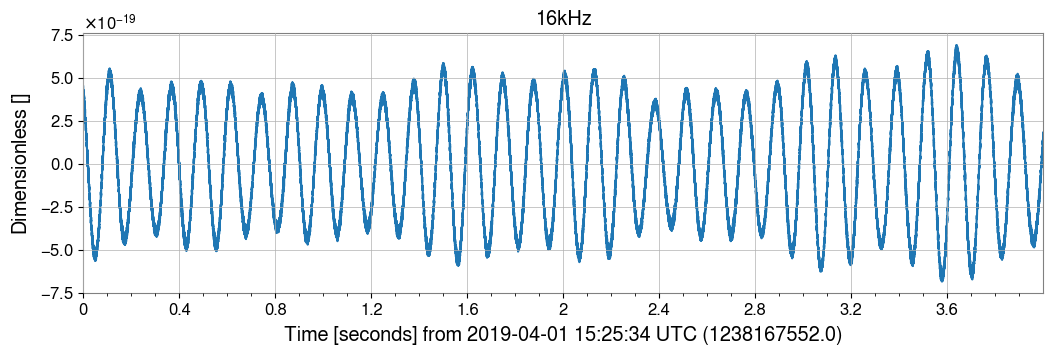

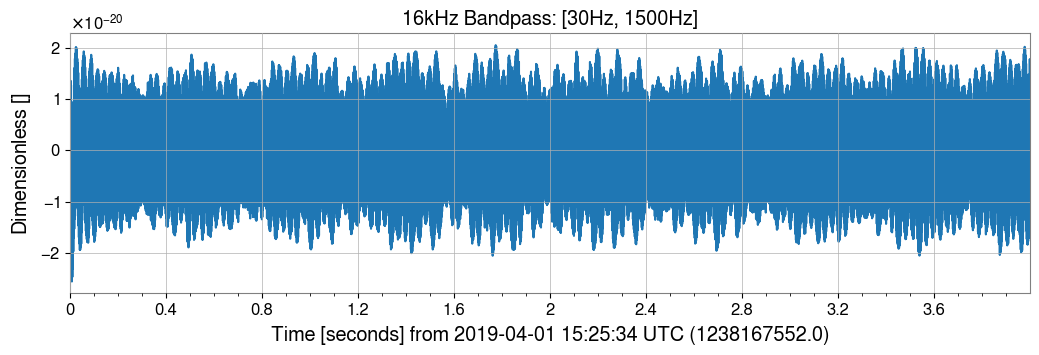

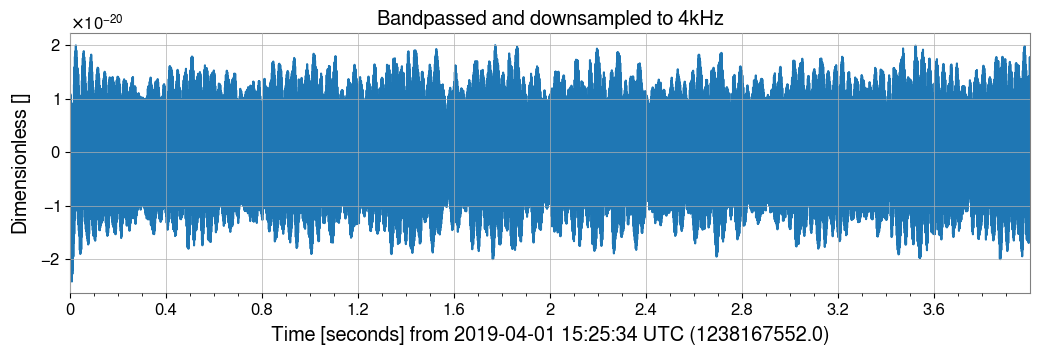

In [9]:
source = glob.glob(f"{DATA_PREFIX}/{IFOS[0]}/*.hdf5")
ts = TimeSeries.read(
    source=source[1],
    format="hdf5.gwosc",
)

print(ts.span)
ts = ts.crop(ts.span.start, ts.span.start+4)
ts.plot(title="16kHz").show()
ts = ts.bandpass(30, 1500)
ts.plot(title="16kHz Bandpass: [30Hz, 1500Hz]").show()
ts = ts.resample(4096)
ts.plot(title="Bandpassed and downsampled to 4kHz").show()